# A Natural Language Processing approach to filtering hate speech in LLM prompts


Group 2 plans to use Media Bias data set to train a NLP model, in detecting biases, such as hate speech or racial bias, focusing more on positive words that are presented in negative contexts, such as sarcasm. And apply that model with LLM prompts dataset.
The aim of the project is to enter deeper into human minds during their interaction with AI models, allowing for a candid understanding of how they communicate and perceive the world around them, as well as glimpses into their mental health.
This model, in the future, hopes to kick start  AI models, especially mental health ai models to approach human prompts with better understanding and different healthier responses.


### Group Members

Varnika, Kaavya Lakshmi, V Venkatesh, Chacko C



### Datasets

Media Bias: https://github.com/Media-Bias-Group/MBIB/blob/main/README.md

@inproceedings{Wessel2023,
title = {Introducing MBIB - the first Media Bias Identification Benchmark Task and Dataset Collection},
author = {Martin Wessel and Tomas Horych and Terry Ruas and Akiko Aizawa and Bela Gipp and Timo Spinde},
url = {https://media-bias-research.org/wp-content/uploads/2023/04/Wessel2023Preprint.pdf
},
doi = {https://doi.org/10.1145/3539618.3591882},
isbn = {978-1-4503-9408-6/23/07},
year = {2023},
date = {2023-07-01},
urldate = {2023-07-01},
booktitle = {Proceedings of the 46th International ACM SIGIR Conference on Research and Development in Information Retrieval (SIGIR ’23)},
publisher = {ACM},
address = {New York, NY, USA},


Prompts: https://huggingface.co/datasets/data-is-better-together/10k_prompts_ranked

**Dataset Loading and Initial Selection**

The initial step involves importing the necessary utilities from the datasets library to manage and combine data. By using the load_dataset function, the "mbib-base" collection is retrieved, which serves as a comprehensive benchmark for media bias. From this dictionary-like object, specific subsets for hate speech and racial bias are extracted and assigned to individual variables. This process serves to isolate the relevant categories of data required for the specific analysis or model training tasks ahead.

In [ ]:
from datasets import load_dataset, concatenate_datasets
import random
dataset_dict = load_dataset("mediabiasgroup/mbib-base")
hate_dataset=dataset_dict['hate_speech']
racial_dataset=dataset_dict['racial_bias']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

cognitive-bias.csv: 0.00B [00:00, ?B/s]

fake-news.csv: 0.00B [00:00, ?B/s]

gender-bias.csv: 0.00B [00:00, ?B/s]

...

Generating hate_speech split:   0%|          | 0/339010 [00:00<?, ? examples/s]

Generating linguistic_bias split:   0%|          | 0/401862 [00:00<?, ? examples/s]

Generating political_bias split:   0%|          | 0/17704 [00:00<?, ? examples/s]

Generating racial_bias split:   0%|          | 0/9788 [00:00<?, ? examples/s]

Generating text_level_bias split:   0%|          | 0/9018 [00:00<?, ? examples/s]

**Filtering and Previewing Hate Samples**

This section performs a targeted filter on the hate speech subset to isolate examples where the label is set to 1. By applying a lambda function, the dataset is narrowed down to only include instances that meet this specific criteria. The first five results are then converted into a Pandas DataFrame, which organizes the raw data into a structured table. The primary function of this step is to provide a clear, readable preview of the positive class samples, ensuring that the data conforms to expected formats before further processing occurs

In [ ]:
filtered_table = pd.DataFrame(
    hate_dataset.filter(lambda x: x['label'] == 1)[:5]
)

filtered_table

,id,text,label,dataset_id
0,040-396446,Don t worry Trump is only holding a 4 to 8 yea...,1,40
1,040-1935550,Even though President Donald Trump finally joi...,1,40
2,040-1682395,Presume for a moment that your premise is corr...,1,40
3,040-399144,I think the Orcas are saying among themselves ...,1,40
4,040-330731,MORON,1,40


**Filtering and Previewing Racial Bias Samples**

In this step, a filter is applied to the racial bias dataset to isolate entries where the label is designated as 1. Using a lambda function, the dataset is refined to include only the relevant instances of racial bias for observation. These first five filtered examples are then wrapped into a Pandas DataFrame to generate a structured tabular view. This function allows for a direct comparison between the content and the labels, ensuring the data is correctly categorized and ready for the next stages of the pipeline.

In [ ]:
filtered_table = pd.DataFrame(
    racial_dataset.filter(lambda x: x['label'] == 1)[:5]
)

filtered_table

Filter:   0%|          | 0/9788 [00:00<?, ? examples/s]

,id,text,label,dataset_id
0,075-2465,um no he is old enough he can wash his own dam...,1,75
1,110-394,RT troy Jerusalem is in fucking africa how the...,1,110
2,075-2704,its all fun and games until the cleaning lady ...,1,75
3,075-46,jews are greedy and have long noses,1,75
4,075-5408,this is like citing an islamist to prove that ...,1,75


**Dataset Diagnostics and Comparative Analysis**

This block of code implements a comprehensive diagnostic suite to evaluate the characteristics of the loaded datasets. A custom function, dataset_diagnostics, is defined to automate the calculation of total sample counts, label distributions, and sentence length statistics for any given input. By applying this function to both the hate speech and racial bias datasets, the script provides a clear overview of data balance and text complexity. Following the individual diagnostics, the code calculates the size ratio between the two datasets to identify potential dominance by one category and utilizes CountVectorizer to perform a vocabulary analysis. By extracting and comparing the unique word sets (excluding common English stop words), the script determines the percentage of shared vocabulary, which is essential for understanding how much linguistic overlap exists between the two distinct bias types.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

def dataset_diagnostics(df, name):
    print(f"\n {name.upper()} DATASET")

    print("Total samples:", len(df))
    print("Label distribution (1 = correct, 0 = wrong):")
    print(
        pd.Series(df['label'])
        .value_counts(normalize=True)
        .rename({1: 'Correct (1)', 0: 'Wrong (0)'})
        .round(3)
    )

    lengths = pd.Series(df['text']).str.split().str.len()
    print("\nSentence length (words):")
    print(lengths.describe()[['mean', '50%', 'max']].round(1))

    return lengths.mean()

#Basic Checks

hate_len = dataset_diagnostics(hate_dataset, "Hate")
racial_len = dataset_diagnostics(racial_dataset, "Racial")


# Dataset dominance check

print("\n DATASET SIZE RATIO ")
print(f"Hate : Racial = {len(hate_dataset)} : {len(racial_dataset)}")
print("Ratio =", round(len(hate_dataset) / len(racial_dataset), 2))


# Vocabulary overlap check

vectorizer = CountVectorizer(min_df=5, stop_words='english')

hate_vocab = set(vectorizer.fit(hate_dataset['text']).get_feature_names_out())
racial_vocab = set(vectorizer.fit(racial_dataset['text']).get_feature_names_out())

overlap = hate_vocab & racial_vocab

print("\n VOCABULARY ANALYSIS ")
print("Hate vocab size:", len(hate_vocab))
print("Racial vocab size:", len(racial_vocab))
print("Shared vocab size:", len(overlap))
print("Vocabulary overlap (%):",
      round(len(overlap) / min(len(hate_vocab), len(racial_vocab)) * 100, 2))




 HATE DATASET
Total samples: 339010
Label distribution (1 = correct, 0 = wrong):
Wrong (0)      0.5
Correct (1)    0.5
Name: proportion, dtype: float64

Sentence length (words):
mean     50.4
50%      35.0
max     312.0
dtype: float64

 RACIAL DATASET
Total samples: 9788
Label distribution (1 = correct, 0 = wrong):
Wrong (0)      0.5
Correct (1)    0.5
Name: proportion, dtype: float64

Sentence length (words):
mean    17.9
50%     18.0
max     41.0
dtype: float64

 DATASET SIZE RATIO 
Hate : Racial = 339010 : 9788
Ratio = 34.64

 VOCABULARY ANALYSIS 
Hate vocab size: 41818
Racial vocab size: 2290
Shared vocab size: 2282
Vocabulary overlap (%): 99.65


**Environment Setup and Dependency Installation**

This command initiates the installation of the essential software libraries required for the project's machine learning and data processing tasks. By using pip, the script fetches and installs datasets for data handling, transformers for accessing pre-trained NLP models, torch for deep learning operations, and scikit-learn for traditional machine learning utilities and evaluation metrics. Executing this step ensures that the Google Colab environment is equipped with all the necessary tools to build, train, and evaluate the models successfully.

In [ ]:
!pip install datasets transformers torch scikit-learn

**Library Imports for Model Training and Evaluation**

This code block imports the core components from the Hugging Face Transformers library and the PyTorch framework to facilitate supervised learning. By loading AutoTokenizer and AutoModelForSequenceClassification, the script gains the ability to process text and initialize a pre-trained model architecture for binary or multi-class classification. Additionally, the TrainingArguments and Trainer classes are imported to streamline the configuration and execution of the training loop, while scikit-learn metrics like accuracy and F1-score are brought in to provide a quantitative assessment of the model's performance. The primary function of these imports is to establish the high-level API framework necessary for fine-tuning a transformer model on the specific bias datasets.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from transformers import TrainingArguments, Trainer
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

**Text Preprocessing Preparation and Warning Management**

This snippet prepares the environment for data cleaning and ensures a clutter-free output during execution. By importing the re and string modules, the script gains the necessary tools for regular expression pattern matching and string manipulation, which are essential for removing punctuation or special characters from the text. Additionally, the warnings library is used to suppress non-critical system alerts, such as deprecation notices. The primary purpose of this block is to set up a clean workspace and provide the foundational utilities required to standardize the text data before it is fed into the model.

In [ ]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

**Text Normalization and Cleaning Function**

This block defines a standardized text preprocessing function designed to clean raw input data before it is tokenized. The clean_text function performs several sequential operations: it converts all text to lowercase, removes HTML tags and URLs, and strips out punctuation and numerical digits. Finally, it collapses multiple spaces into a single space and trims any leading or trailing whitespace. The primary purpose of this function is to reduce noise and ensure linguistic consistency, allowing the model to focus on the core semantic content of the messages rather than formatting inconsistencies or irrelevant characters.

In [ ]:
def clean_text(text):
  if text is None: return ""
  text = str(text).lower()
  text = re.sub(r'<[^>]*>', '', text)
  text = re.sub(r'http\S+|www\S+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

# Hate Dataset

**Model Selection and Tokenizer Initialization**

This section defines the foundation for the transformer-based workflow by specifying a pre-trained model architecture. By selecting "bert-base-uncased", the script chooses a widely-used version of the BERT model that does not distinguish between uppercase and lowercase letters, which aligns with the text normalization performed in previous steps. The AutoTokenizer.from_pretrained function then downloads and caches the specific vocabulary and configuration associated with this model. This serves the critical function of ensuring that the input text is converted into the exact numerical format and token IDs that the BERT model was originally trained to understand.

In [ ]:
model_name="bert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

**Data Tokenization and Train-Test Splitting**

This block of code implements the final transformation of the raw text into a format compatible with the neural network. A tokenize_function is defined to process the data, ensuring that every sequence is padded to a consistent length of 254 tokens or truncated if it exceeds that limit; this uniformity is crucial for batch processing during training. By applying this function across the dataset using the map method, the entire corpus is converted into numerical input IDs and attention masks. Finally, the processed data is partitioned into training and testing sets with a 20% split, using a fixed seed to ensure that the results are reproducible. This step establishes the independent datasets necessary for both teaching the model and objectively evaluating its final performance.

In [ ]:
def tokenize_function(examples):
  return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=254)

tokenized_datasets=hate_dataset.map(tokenize_function, batched=True)

split_dataset = tokenized_datasets.train_test_split(test_size=0.2, seed=42)


Map:   0%|          | 0/339010 [00:00<?, ? examples/s]

**Dataset Resampling and Subsetting**

This section of the code handles the final preparation of the training and testing sets by introducing randomization and size constraints. To ensure the model does not learn from any inherent ordering in the data, both the training and testing subsets are shuffled using a fixed seed for reproducibility. Following the shuffle, the datasets are sliced to select 5,000 samples for training and 1,000 samples for evaluation. This function is particularly useful for optimizing computational resources, as it creates a manageable yet representative sample of the data, allowing for faster experimentation and iteration while still providing enough examples for the model to learn effectively.

In [ ]:
train_dataset = split_dataset["train"].shuffle(seed=42).select(range(5000))
test_dataset  = split_dataset["test"].shuffle(seed=42).select(range(1000))

**Dataset Structure Verification**

This command outputs the internal structure and metadata of the split_dataset object, providing a clear overview of the partitioned data. By printing this object, the results display the number of rows (samples) and the specific columns (such as input_ids, attention_mask, and labels) available in both the training and testing sets. This serves as a vital validation step to confirm that the splitting, tokenization, and mapping processes were successful, ensuring the dataset is correctly organized before it is passed into the training loop.

In [ ]:
print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 271208
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 67802
    })
})


**PyTorch Tensor Conversion and Format Standardization**

This section configures the internal storage format of the datasets to be compatible with the PyTorch deep learning framework. By calling set_format, the script ensures that the specified columns—including raw data like text and model-ready inputs like input_ids and attention_mask—are treated as PyTorch tensors rather than standard Python objects or NumPy arrays. This transformation is a critical prerequisite for the training process, as it allows the data to be loaded directly onto hardware accelerators like GPUs for high-speed mathematical operations.

In [ ]:
#set format for PyTorch
train_dataset.set_format("torch", columns=['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'])
test_dataset.set_format("torch", columns=['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'])

**Model Initialization for Binary Classification**

This line of code initializes the sequence classification model using the pre-trained weights specified by the model_name. By utilizing AutoModelForSequenceClassification.from_pretrained, the script loads the BERT architecture with a custom classification head attached to the top. The num_labels=2 parameter explicitly configures the model for a binary classification task, such as distinguishing between "bias" and "no bias." This step is the core of the transfer learning process, as it leverages the vast linguistic knowledge already captured in the base model while preparing it to be fine-tuned on the specific nuances of the hate speech and racial bias datasets.

In [ ]:
model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Model Evaluation Metrics Definition**

This block defines a custom function used to evaluate the model's predictive performance during the training and testing phases. The compute_metrics function takes the raw predictions from the model, identifies the highest-probability class for each sample using the argmax operation, and compares these predictions against the ground-truth labels. By calculating accuracy, precision, recall, and the F1-score, the script provides a multi-dimensional view of how well the model identifies biased content. This function is essential for understanding the balance between correctly identified instances and false positives, ensuring the model is reliable and effective across different evaluation criteria.

In [ ]:
def compute_metrics(pred):
  labels=pred.label_ids
  preds=pred.predictions.argmax(-1)
  precision, recall, f1, _=precision_recall_fscore_support(labels, preds, average="binary")
  acc=accuracy_score(labels, preds)
  return{"accuracy":acc, "f1":f1, "precision":precision, "recall":recall}

**Initializing the Specialized Trainer**

This code block sets up the Trainer object specifically for your dataset, consolidating the model, hyperparameters, and data into a single execution engine. By defining training_args, you establish the "rules" of the training run:

num_train_epochs=3: The model will pass through the entire dataset three times.

per_device_train_batch_size=8: The model processes 8 examples at a time, balancing memory usage with training stability.

Logging/Reporting: By setting these to "no" and [], you ensure a clean console output without external tracking overhead.

The Trainer object then links these settings with your train_dataset and test_dataset, using the compute_metrics function to keep a pulse on the model's accuracy as it learns. This modular approach makes it easy to swap datasets or models while keeping the training logic consistent.

In [ ]:
from transformers import TrainingArguments, Trainer

training_args=TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    #evaluation strategy="epoch",
    logging_strategy="no", #disables logging
    report_to=[], # disables W&B,TensorBoards, etc
)

trainer_hate=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

**Commencing the Model Fine-Tuning**

Executing trainer_hate.train() starts the engine that adjusts the model's internal parameters. During this process, the model reads the training samples in batches of 8 (as defined in your arguments), calculates the difference between its predictions and the actual labels (the "loss"), and uses optimization algorithms to minimize that error.

Over the course of the 3 epochs, you will typically see the training loss decrease. This indicates that the BERT model is successfully moving away from its general language understanding and specializing in the specific patterns, vocabulary, and nuances associated with the hate speech and racial bias categories you've provided.

In [ ]:
trainer_hate.train()

Step,Training Loss


TrainOutput(global_step=1875, training_loss=0.2748410807291667, metrics={'train_runtime': 711.3805, 'train_samples_per_second': 21.086, 'train_steps_per_second': 2.636, 'total_flos': 1957916251800000.0, 'train_loss': 0.2748410807291667, 'epoch': 3.0})

**Final Performance Validation**

The trainer_hate.evaluate() command performs a final, comprehensive check of the model’s performance on the test dataset. Unlike the training phase, this step does not update the model's weights; instead, it uses the "unseen" data to provide an objective report on how well the model has learned to identify Hate Speech and Racial Bias.

The output will yield a dictionary of metrics, including the F1-score and accuracy, which were defined in your compute_metrics function. This is the moment of truth where you can see if the model can generalize its knowledge to new text or if it simply memorized the training examples.

In [ ]:
trainer_hate.evaluate()

{'eval_loss': 0.6619167327880859,
 'eval_accuracy': 0.864,
 'eval_f1': 0.8682170542635659,
 'eval_precision': 0.8311688311688312,
 'eval_recall': 0.9087221095334685,
 'eval_runtime': 16.1194,
 'eval_samples_per_second': 62.037,
 'eval_steps_per_second': 7.755,
 'epoch': 3.0}

**Generating Predictions on the Test Set**

This code block uses your newly trained model to make actual predictions on the test_dataset. It follows a three-step logic to translate raw model output into human-readable categories:

trainer_hate.predict: The model processes the test samples and returns a PredictionOutput object. This includes the "logits," which are the raw, unnormalized scores for each of your three classes (Neutral, Hate Speech, and Racial Bias).

argmax(axis=-1): Because the model outputs a score for every class, we use argmax to select the index of the highest score. For example, if the scores are $[-1.2, 3.5, 0.2]$, the function picks index 1 (Hate Speech).

print(pred_labels[:20]): This displays the first 20 predicted class IDs ($0, 1,$ or $2$), allowing you to verify that the model is indeed predicting different categories rather than just outputting the same number for everything.

In [ ]:
pred_output = trainer_hate.predict(test_dataset)

pred_logits = pred_output.predictions
pred_labels = pred_logits.argmax(axis=-1)

print(pred_labels[:20])

[0 0 0 0 0 1 1 1 1 0 0 0 1 1 0 0 0 1 0 1]


**Identifying and Isolating Specific Class Predictions**

This script utilizes NumPy to filter and inspect the specific instances where your model identified content as Label 1 (Hate Speech).

After generating the pred_labels using argmax, the np.where function scans the entire array to find every index where the predicted class matches your target. This is an essential diagnostic step for:

Volume Verification: Understanding how frequently the model is flagging content as hate speech compared to your expectations.

Manual Review: Identifying specific row indices so you can look back at the original text in your test_dataset and verify if the model's "judgment" was accurate.

Error Analysis: Spotting if the model is being over-aggressive (too many label 1s) or too lenient (too few label 1s).

In [ ]:
import numpy as np

pred_output = trainer_hate.predict(test_dataset)

pred_logits = pred_output.predictions
pred_labels = pred_logits.argmax(axis=-1)

# indices where prediction == 1
idx_label1 = np.where(pred_labels == 1)[0]

print("Number of samples predicted as label 1:", len(idx_label1))
print("First 20 indices predicted as 1:", idx_label1[:20])

Number of samples predicted as label 1: 935
First 20 indices predicted as 1: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


**Manual Prediction Inspection**

This loop iterates through the first twenty instances identified as Label 1 to retrieve and display the original text associated with those specific indices. By pulling the raw content from the test dataset, the code provides a direct way to compare the model's automated classification against the actual input text. This process serves as a qualitative check, revealing whether the model is accurately capturing the nuances of the assigned category or if it is being influenced by specific keywords in the data.

In [ ]:
for i in idx_label1[:20]:
    i = int(i)
    print(f"Index: {i}")
    print("Text:", test_dataset[i]["text"])
    print()

Index: 0
Text: i want to speak to eaw manager im jewish and this deeply offends me not all jews are greedy 

Index: 1
Text: theres certainly a stereotype that african americans are horrible tippers i dont know how accurate it is since ive never worked in that industry

Index: 2
Text: lel no guys he cooking caus his wife is too tired

Index: 3
Text: being transgender is not a mental disorder 

Index: 4
Text: the dude was calling people faggot in the discord and apparently said all homosexuals are all pedophiles at one point 

Index: 5
Text: surprise surprise muslims killing people when they dont get what they want islam is a disgusting evil dangerous and violent cult 

Index: 6
Text: funny thing is half girlfriend is an indian novel

Index: 7
Text: only thing arabs hate more than non arabs are other arabs

Index: 8
Text: whahuhh really kinda depressing that people still think that gays are solely sexual

Index: 9
Text: right now on their front page they are saying that muslims are a thr

**Inference and Confidence Scoring on Sample Sentences**

This script performs a complete inference cycle on a set of sample sentences using a pre-trained classification model. After loading the model and tokenizer, it converts raw text into numerical tensors and passes them through the network while disabling gradient calculations to optimize performance. The resulting raw scores, or logits, are transformed into probabilities using a softmax function, and an argmax operation is used to identify the final predicted label. By outputting the prediction alongside a confidence score for each text, the code provides a clear view of how the model distinguishes between different types of language, such as civil discourse and biased statements.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
model.eval()

texts = [
    "People like you should go back to where you came from",
    "I disagree with your opinion but respect your right to say it",
    "This group is ruining our country",
    "Let us have a civil discussion about policy"
]

inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

print("\nPredictions per text:\n")
for text, pred, prob in zip(texts, preds, probs):
    label = "Label 1 (Positive)" if pred.item() == 1 else "Label 0 (Negative)"
    confidence = prob[pred.item()].item()
    print(f"Text: {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.3f}\n")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Predictions per text:

Text: People like you should go back to where you came from
Prediction: Label 1 (Positive)
Confidence: 0.526

Text: I disagree with your opinion but respect your right to say it
Prediction: Label 1 (Positive)
Confidence: 0.525

Text: This group is ruining our country
Prediction: Label 1 (Positive)
Confidence: 0.523

Text: Let us have a civil discussion about policy
Prediction: Label 1 (Positive)
Confidence: 0.522



**Model Inference on a Single Text Sample**

This script demonstrates the process of using a pre-trained model and its corresponding tokenizer to classify a specific, multi-sentence string of text. The code converts the raw text into a structured numerical format while ensuring it adheres to length constraints through padding and truncation. By performing a forward pass without calculating gradients, the script efficiently extracts raw prediction scores, known as logits, and identifies the final category index using the argmax function. This allows for a direct observation of how the model interprets and categorizes complex language patterns in a practical, real-world scenario.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

text = "Presume for a moment that your premise is correct that voters don t feel they can wisely vote because they ain t up to snuff Two things 1 phoney on them Grow up pay attention get informed I don t mean listen to what tutu said to vote for or your stupid union rep either and get smart Then vote 2 government shouldn t be constantly trying to do so much and be freaking agents of change such that they are always tackling issues that would require us to constantly pay attention to and have to learn about If government went a whole year without passing any new laws THAT would be progress."
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
pred = torch.argmax(logits, dim=1).item()

print("Predicted Label:", pred)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Predicted Label: 0


**Loading an External Dataset**

This code utilizes a popular data-hosting library to retrieve a specific collection of text data for training or evaluation. By calling the loading function with the identifier for a ranked prompts dataset, the script downloads the necessary files and selects the "train" portion of the data for use. This process creates a structured object in memory, allowing for immediate access to various features like prompts and their quality rankings, which can then be used for further analysis or model fine-tuning.

In [ ]:
from datasets import load_dataset

ds = load_dataset("data-is-better-together/10k_prompts_ranked", split="train")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10331 [00:00<?, ? examples/s]

**Efficient Batch Tokenization**

This code defines a preprocessing function that converts raw text from the dataset into a format suitable for neural network models. By applying this function across the entire dataset using a batching approach, the script efficiently handles large volumes of text while ensuring each sequence is padded or truncated to a consistent length. This step is essential for preparing the data, as it creates the necessary numerical representations that the model uses to understand and process the input information.

In [ ]:
def preprocess_fn(examples):
    return tokenizer(examples["prompt"], truncation=True, padding=True)

tokenized_ds = ds.map(preprocess_fn, batched=True)

Map:   0%|          | 0/10331 [00:00<?, ? examples/s]

**Generating Predictions on the Full Dataset**

This line of code executes the trained model's inference logic across the entire tokenized dataset to generate a comprehensive set of predictions. By using the predict method, the system processes the input sequences and returns a structured object containing the raw output scores and original labels. This step is essential for assessing how the model generalizes to a new collection of text, providing the necessary data to evaluate performance metrics or analyze the distribution of predicted categories across the entire sample set.

In [ ]:
pred_results = trainer_hate.predict(tokenized_ds)

**Dataset Structure Verification**

This command retrieves and displays the names of all existing columns within the tokenized dataset object. By checking these attributes, you can verify that the preprocessing steps—such as tokenization and padding—successfully added the required model inputs, like input_ids and attention_mask, alongside the original text and label fields. Understanding the available column names is a standard diagnostic step used to ensure the data structure is correctly formatted before passing it into a training or evaluation loop.

In [ ]:
tokenized_ds.column_names

['prompt',
 'quality',
 'metadata',
 'avg_rating',
 'num_responses',
 'agreement_ratio',
 'raw_responses',
 'kind',
 'cluster_description',
 'topic',
 'input_ids',
 'token_type_ids',
 'attention_mask']

**Class Prediction Extraction**

This code utilizes NumPy to convert the model's raw numerical outputs into specific class predictions across the dataset. By applying the argmax function to the raw scores, or logits, the script identifies which category received the highest score for every input sample. This transformation is a necessary step in the post-processing pipeline, as it shifts the data from abstract model values to a list of concrete labels that can be directly compared against the ground truth or used for final reporting.

In [ ]:
import numpy as np

logits = pred_results.predictions
preds = np.argmax(logits, axis=-1)

**Exporting Predictions to CSV**

This script integrates the model's generated predictions directly back into the dataset by creating a new column for the predicted labels. Once the data is updated, it uses a built-in function to export the entire collection, including the original prompts and their new classifications, into a CSV file. This creates a permanent, portable record of the results that can be easily opened in spreadsheet software for manual review or further data analysis without needing to re-run the computationally expensive model inference.

In [ ]:
ds = ds.add_column("predicted_label", preds)
output_filename = "hate_predictions_on_10k_prompts.csv"
ds.to_csv(output_filename)
print(f" Classification complete. Results saved to {output_filename}")

Creating CSV from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

 Classification complete. Results saved to hate_predictions_on_10k_prompts.csv


**Identifying Sarcasm Through Lexical Contrast**

This script utilizes the VADER sentiment analysis library to detect linguistic irony by searching for highly positive vocabulary within text previously flagged as biased or hateful. By analyzing individual words and filtering for those with extreme positivity scores, the code identifies instances where complimentary language is used in a potentially sarcastic or contradictory manner. This method allows for a deeper examination of the data, isolating specific examples where the model's classification might overlap with complex rhetorical devices, thereby helping to distinguish between direct hostility and more nuanced forms of biased communication.

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the vader_lexicon if not already present
nltk.download('vader_lexicon')

# CRITICAL: Initialize SIA inside the execution block
sia = SentimentIntensityAnalyzer()

def find_positive_words_in_bias(text):
    positive_words = []
    if not isinstance(text, str): return "" # Safety check
    words = text.lower().split()

    for word in words:
        # Look for words with a high positive score (close to perfect positivity)
        score = sia.polarity_scores(word)['pos']
        if score > 0.9:
            positive_words.append(word)

    return ", ".join(positive_words)

# Load and Filter Data
classified_file = "hate_predictions_on_10k_prompts.csv"
df = pd.read_csv(classified_file)

# Filter for the usable biased prompts (Hate Speech, Label 1)
# Include Label 2 just in case, but results will be dominated by Label 1
biased_df = df[df['predicted_label'].isin([1, 2])].copy()

# Apply Sarcasm Detection
biased_df['positive_words_in_bias'] = biased_df['prompt'].apply(find_positive_words_in_bias)

# Filter for Candidates (Where a strong positive word was found)
irony_candidates = biased_df[biased_df['positive_words_in_bias'].str.len() > 0]

print(f"Total Biased Prompts Analyzed: {len(biased_df)}")
print(f"Found {len(irony_candidates)} potential ironic/sarcastic candidates.")

print("\n Example Prompts with Positive Words in a Biased Context")
# Show the prompt, the predicted bias, and the positive word identified by VADER
print(irony_candidates[['prompt', 'predicted_label', 'positive_words_in_bias']].head(10))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Total Biased Prompts Analyzed: 131
Found 86 potential ironic/sarcastic candidates.

 Example Prompts with Positive Words in a Biased Context
                                                prompt  predicted_label  \
19   Explain simply why no is the correct answer to...                1   
212  Hey can you create an outline for a video scri...                1   
346  With no explanation, label A→B with either "no...                1   
393  write a promo for a new campaign called "just ...                1   
474  AI can now be used to impersonate someone's vo...                1   
512  Title: "(20) The Summit - YouTube"\nVideo Tran...                1   
728  Can you pretend to be a angry human who is whi...                1   
782   What are good role models for my 10 yo daughter?                1   
922  !2 / 2write a screenplay in which trump and bi...                1   
937  Can you provide more information about the Tem...                1   

                                p

Confusion Matrix for Hate Dataset

**Model Evaluation Metric Calculation**

This code block prepares the necessary components for a detailed performance analysis by converting raw model outputs into interpretable statistical data. It retrieves the logits and true labels from the evaluation dataset and applies a mathematical transformation to convert those raw scores into probabilities. By identifying the highest probability for each sample to determine the predicted class, the script establishes a direct comparison between the model's decisions and the actual ground truth. This setup provides the foundation for generating a confusion matrix and other diagnostic reports that reveal exactly how well the model distinguishes between different categories.

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Get raw predictions
predictions = trainer_hate.predict(trainer_hate.eval_dataset)

# Logits → probabilities
logits = predictions.predictions
labels = predictions.label_ids

# For binary classification
probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
y_pred = np.argmax(probs, axis=1)
y_true = labels


**Unique Label Verification**

This code uses NumPy to identify and list every distinct class label present in both the actual ground truth and the model's predictions. By extracting the unique values from these arrays, the script allows for a quick verification that the model is outputting the expected range of categories and that no unintended labels were introduced during the evaluation process. This is a vital diagnostic step to ensure that the evaluation set contains all target classes and that the model is successfully predicting across the entire intended label space.

In [ ]:
np.unique(y_true), np.unique(y_pred)

(array([0, 1]), array([0, 1]))

**Comprehensive Performance Visualization and Reporting**

This script generates a detailed statistical and visual breakdown of the model's classification accuracy using standard evaluation metrics. By creating a confusion matrix, the code visually displays how many samples were correctly identified and which categories were most frequently confused, while the classification report provides precise values for precision, recall, and F1-score. Additionally, the script plots a Receiver Operating Characteristic (ROC) curve and calculates the Area Under the Curve (AUC) to measure the model's ability to distinguish between classes at various threshold levels. Together, these tools provide a clear picture of the model's reliability and its effectiveness in identifying hate speech compared to non-hateful content.

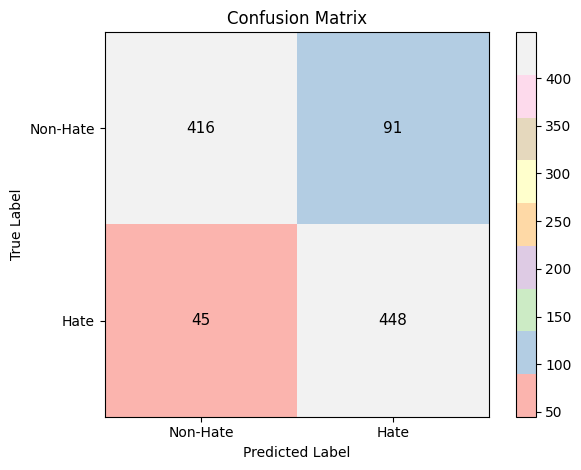


 Classification Report 
              precision    recall  f1-score   support

    Non-Hate       0.90      0.82      0.86       507
        Hate       0.83      0.91      0.87       493

    accuracy                           0.86      1000
   macro avg       0.87      0.86      0.86      1000
weighted avg       0.87      0.86      0.86      1000



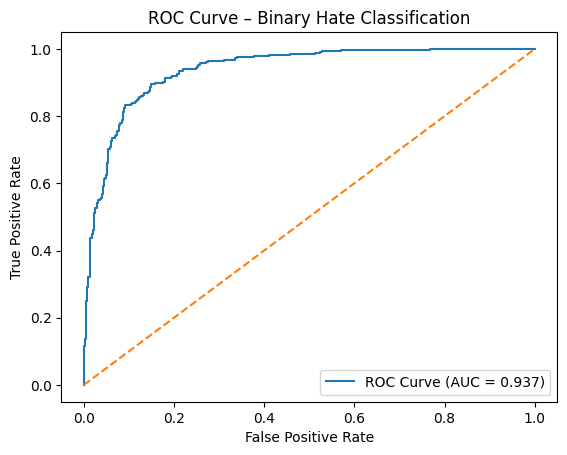

ROC–AUC Score: 0.9374


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

predictions = trainer_hate.predict(trainer_hate.eval_dataset)

logits = predictions.predictions
y_true = predictions.label_ids


probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
y_pred = np.argmax(probs, axis=1)


cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, cmap=plt.cm.Pastel1)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Non-Hate", "Hate"])
plt.yticks([0, 1], ["Non-Hate", "Hate"])

# Add black text annotations
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.colorbar()
plt.tight_layout()
plt.show()


print("\n Classification Report ")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-Hate", "Hate"]
))


fpr, tpr, _ = roc_curve(y_true, probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Binary Hate Classification")
plt.legend()
plt.show()

print(f"ROC–AUC Score: {roc_auc:.4f}")


**Model Serialization and Storage**

This code executes the process of saving the fine-tuned model and its associated configuration files to a specified local directory. By invoking the save method, the script ensures that the learned weights, architecture settings, and tokenizer details are preserved in a format that can be easily reloaded for future use. This step is critical for transitioning from the training phase to deployment, as it captures the current state of the model and allows it to be shared or used for inference without needing to repeat the resource-intensive training process.

In [ ]:
save_dir = "./hate_binary_model"

trainer_hate.save_model(save_dir)

# Racial Dataset

**Tokenizer Initialization**

This script initializes the specific text-processing component required to prepare data for a standard transformer architecture. By loading the pre-trained configuration associated with the base uncased model, the code ensures that the raw input text will be split into the exact subword units and numerical IDs that the model was originally designed to process. This foundational step is necessary for maintaining consistency between the training environment and the current application, as it provides the mapping system needed to translate human language into machine-readable tensors.

In [ ]:
model_name="bert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(model_name)

**Accessing a Specific Data Subset**

This line of code retrieves a targeted collection of data from a larger dictionary-like structure containing multiple categorized datasets. By specifying the key for racial bias, the script isolates that particular subset for focused analysis or model training, allowing for the inspection of language patterns specific to that category. This organizational step is common when working with multi-task or multi-domain data, as it enables the application of specialized preprocessing or evaluation techniques to a single thematic area without affecting the rest of the data.

In [ ]:
racial_dataset = dataset_dict['racial_bias']

**Data Tokenization and Splitting**

This code prepares the racial bias dataset for model training by converting the raw text into a fixed-length numerical format and dividing the data into distinct sets. The preprocessing function applies tokenization with a specific maximum length of 254 characters, ensuring that all inputs are uniform through padding and truncation. Once the entire dataset is transformed, it is partitioned into a training set and a testing set using an 80/20 split, with a fixed random seed to ensure the results are reproducible. This structured approach is essential for training the model on one portion of the data while reserving the other to objectively measure its performance.

In [ ]:
def tokenize_function(examples):
  return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=254)

tokenized_datasets=racial_dataset.map(tokenize_function, batched=True)

split_dataset = tokenized_datasets.train_test_split(test_size=0.2, seed=42)


Map:   0%|          | 0/9788 [00:00<?, ? examples/s]

**Dataset Downsampling and Randomization**

This script creates smaller, manageable subsets of the data by shuffling the training and testing sets and selecting a specific number of samples from each. By applying a fixed seed during the shuffle, the code ensures that the randomization is consistent every time the script is run, which is crucial for experimental reproducibility. Selecting 5,000 samples for training and 1,000 for testing helps reduce the computational resources and time required for the initial phases of model development, allowing for faster iteration while still maintaining a representative sample of the overall data distribution.

In [ ]:
train_dataset = split_dataset["train"].shuffle(seed=42).select(range(5000))
test_dataset  = split_dataset["test"].shuffle(seed=42).select(range(1000))

**Dataset Structure Overview**

This command provides a high-level summary of the internal organization and metadata of the dataset object after the splitting process. The output displays the number of rows contained within both the training and testing portions, as well as the specific features or columns available, such as input_ids, attention_mask, and the original labels. Reviewing this summary is a standard verification step to confirm that the data has been partitioned correctly and that the preprocessing steps have successfully generated the necessary numerical inputs required for the model's training pipeline.

In [ ]:
print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7830
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1958
    })
})


**Tensors for Machine Learning Frameworks**

This code configures the internal structure of the datasets to ensure they are fully compatible with the PyTorch deep learning framework. By explicitly setting the format to "torch" and specifying the necessary columns—including both raw metadata and model-specific tensors like input_ids and attention_mask—the script prepares the data for seamless integration into a training loop or data loader. This step is essential because it transforms standard data structures into the high-performance tensor format required for GPU acceleration and backpropagation during the model optimization process.

In [ ]:
#set format for PyTorch
train_dataset.set_format("torch", columns=['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'])
test_dataset.set_format("torch", columns=['id', 'text', 'label', 'dataset_id', 'input_ids', 'token_type_ids', 'attention_mask'])

**Model Architecture Initialization**

This code initializes a transformer-based model specifically configured for sequence classification tasks with two output categories. By loading a pre-trained architecture and specifying the number of labels, the script adapts the model's final layer to perform binary classification, such as distinguishing between neutral and biased text. This approach leverages transfer learning, allowing the system to use the broad linguistic knowledge acquired during its initial training while focusing its specialized final parameters on the specific patterns required for your current dataset.

**Model Architecture Initialization**

This code initializes a transformer-based model specifically configured for sequence classification tasks with two output categories. By loading a pre-trained architecture and specifying the number of labels, the script adapts the model's final layer to perform binary classification, such as distinguishing between neutral and biased text. This approach leverages transfer learning, allowing the system to use the broad linguistic knowledge acquired during its initial training while focusing its specialized final parameters on the specific patterns required for your current dataset.

In [ ]:
model=AutoModelForSequenceClass  ification.from_pretrained(model_name, num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Evaluation Metrics Calculation**

This function defines the logic for assessing model performance by comparing predicted labels against the ground truth during the training and evaluation phases. It calculates four key statistical indicators—accuracy, precision, recall, and F1-score—to provide a balanced view of how well the model identifies the target class. By extracting the highest-scoring prediction for each sample and passing it through standard evaluation formulas, the script produces a dictionary of results that helps monitor whether the model is learning effectively or if it is struggling with specific types of errors, such as false positives or false negatives.

In [ ]:
def compute_metrics(pred):
  labels=pred.label_ids
  preds=pred.predictions.argmax(-1)
  precision, recall, f1, _=precision_recall_fscore_support(labels, preds, average="binary")
  acc=accuracy_score(labels, preds)
  return{"accuracy":acc, "f1":f1, "precision":precision, "recall":recall}

**Training Configuration and Environment Setup**

This script defines the essential parameters and initializes the execution environment for the model's training process. By setting the TrainingArguments, the code controls the number of passes through the data, the size of the data batches processed by the hardware, and where the final results should be stored. The Trainer object then consolidates these settings with the specific model, datasets, and evaluation metrics, creating a streamlined pipeline that manages the complex mathematics of the learning process. This centralized approach simplifies the training loop, ensuring that the model is consistently updated and tested against the validation data according to the predefined strategy.

In [ ]:
from transformers import TrainingArguments, Trainer

training_args=TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    #evaluation strategy="epoch",
    logging_strategy="no", #disables logging
    report_to=[], # disables W&B,TensorBoards, etc
)

trainer_racial=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

**Model Training Execution**

This command initiates the actual fine-tuning process, where the model begins learning from the provided racial bias dataset. During this phase, the system iterates through the training data for the specified number of epochs, adjusting the internal neural network weights to minimize errors and improve classification accuracy. The Trainer handles the complex backend operations, including gradient calculations, weight updates, and periodic evaluations, allowing the model to gradually refine its ability to distinguish between different categories of text based on the patterns it identifies in the training samples.

In [ ]:
trainer_racial.train()

Step,Training Loss


TrainOutput(global_step=1875, training_loss=0.37570751953125, metrics={'train_runtime': 760.9237, 'train_samples_per_second': 19.713, 'train_steps_per_second': 2.464, 'total_flos': 1957916251800000.0, 'train_loss': 0.37570751953125, 'epoch': 3.0})

**Model Performance Assessment**

This command triggers a formal evaluation of the fine-tuned model's performance by running it against the reserved test dataset. The system processes the test samples to calculate the specific metrics defined earlier, such as accuracy, precision, and F1-score, providing an objective measure of how well the model generalizes to new, unseen information. This step is crucial for identifying potential issues like overfitting and for determining the model's actual effectiveness in classifying racial bias before it is deployed for real-world applications.

In [ ]:
trainer_racial.evaluate()

{'eval_loss': 0.9755144715309143,
 'eval_accuracy': 0.791,
 'eval_f1': 0.779768177028451,
 'eval_precision': 0.7939914163090128,
 'eval_recall': 0.7660455486542443,
 'eval_runtime': 14.5005,
 'eval_samples_per_second': 68.963,
 'eval_steps_per_second': 8.62,
 'epoch': 3.0}

**Model Inference and Label Prediction**

This script performs a full prediction pass on the evaluation dataset to generate specific class assignments for each text sample. By extracting the raw logits—the model's unscaled confidence scores—and applying a mathematical function to identify the highest value for each entry, the code converts complex internal calculations into clear numerical labels. Printing the first twenty results allows for a quick manual inspection to ensure the output format aligns with expectations and provides an initial glimpse into the model's decision-making pattern across the test samples.

In [ ]:
pred_output = trainer_racial.predict(test_dataset)

pred_logits = pred_output.predictions
pred_labels = pred_logits.argmax(axis=-1)

print(pred_labels[:20])

[0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 1 0 1]


**Identifying Specific Class Predictions**

This script filters the model's output to isolate and count every instance where a specific category, in this case, "label 1," was predicted. By using NumPy to locate the exact array indices of these occurrences, the code allows you to pinpoint precisely which samples in the dataset the model flagged. This is a practical diagnostic step for understanding the distribution of the model's decisions, providing both a total count of the identified class and a list of the specific records for further manual inspection or targeted analysis of potential bias.

In [ ]:
import numpy as np

pred_output = trainer_racial.predict(test_dataset)

pred_logits = pred_output.predictions
pred_labels = pred_logits.argmax(axis=-1)

# indices where prediction == 1
idx_label1 = np.where(pred_labels == 1)[0]

print("Number of samples predicted as label 1:", len(idx_label1))
print("First 20 indices predicted as 1:", idx_label1[:20])


Number of samples predicted as label 1: 466
First 20 indices predicted as 1: [ 4  5  7 12 17 19 20 24 25 27 32 33 36 39 42 44 49 50 51 52]


**Sample Text Inspection**

This code iterates through a subset of the previously identified indices to display the actual text content that the model classified as "label 1." By converting the index to a standard integer and retrieving the corresponding entry from the test dataset, the script provides a direct look at the specific language patterns that triggered the model's decision. This manual review process is a vital part of error analysis, allowing for the verification of the model's reasoning and the identification of potential false positives or nuances in the data that the model may be interpreting in specific ways.

In [ ]:
for i in idx_label1[:20]:
    i = int(i)   # IMPORTANT
    print(f"Index: {i}")
    print("Text:", test_dataset[i]["text"])
    print()

Index: 4
Text: the dude was calling people faggot in the discord and apparently said all homosexuals are all pedophiles at one point 

Index: 5
Text: surprise surprise muslims killing people when they dont get what they want islam is a disgusting evil dangerous and violent cult 

Index: 7
Text: only thing arabs hate more than non arabs are other arabs

Index: 12
Text: this lady is a housekeeper who specializes in emotional support and working with people struggling she gets glowing reviews

Index: 17
Text: jewish mothers are overbearing and nag too much 

Index: 19
Text: gt black people are all lazy get that in writing and send it to the eeoc they would love to hear about it 

Index: 20
Text: i cant stand ashley the girl is literally addicted to drama 

Index: 24
Text: beautiful i wish the picture in my head translated to what my hand draws my year old niece is far better at art than i 

Index: 25
Text: ew gays are so creepy and weird and gross amp b man who posts creepshots of strange

**Model Inference and Probability Analysis**

This script demonstrates the end-to-end inference process for classifying specific text strings using a pre-trained transformer model. After loading the model and tokenizer, the code prepares a list of sample sentences and converts them into tensors, ensuring they match the input requirements of the architecture. By disabling gradient calculations, the script efficiently computes the raw output scores, which are then transformed into probability distributions using a softmax function. This allows the system to not only assign a final category label to each sentence but also to provide a confidence score, offering insight into how certain the model is about its classification for each individual input.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)
model.eval()

texts = [
    "People like you should go back to where you came from",
    "gt black people are all lazy get that in writing and send it to the eeoc they would love to hear about it ",
    "This group is ruining our country because of their ethnicity",
    "We don't want people of your kind living here"
]

inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)

print("\nPredictions per text:\n")
for text, pred, prob in zip(texts, preds, probs):
    label = "Label 1 (Positive)" if pred.item() == 1 else "Label 0 (Negative)"
    confidence = prob[pred.item()].item()
    print(f"Text: {text}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.3f}\n")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Predictions per text:

Text: People like you should go back to where you came from
Prediction: Label 0 (Negative)
Confidence: 0.554

Text: gt black people are all lazy get that in writing and send it to the eeoc they would love to hear about it 
Prediction: Label 1 (Positive)
Confidence: 0.506

Text: This group is ruining our country because of their ethnicity
Prediction: Label 0 (Negative)
Confidence: 0.546

Text: We don't want people of your kind living here
Prediction: Label 0 (Negative)
Confidence: 0.542



**Single Sequence Inference Execution**

This script performs a targeted prediction on a specific text string to determine its classification according to the loaded model. By processing the raw text through the tokenizer and passing the resulting tensors into the neural network, the code generates numerical scores known as logits. The final decision is extracted by identifying the index of the highest score, providing a clear categorical output for the individual input. This streamlined workflow is the standard method for testing how a model responds to specific phrases or for integrating the model into a real-time application where single-sentence analysis is required.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

text = "Brown men love curry"
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
pred = torch.argmax(logits, dim=1).item()

print("Predicted Label:", pred)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Predicted Label: 1


**External Dataset Integration**

This code utilizes a specialized library to download and load a specific collection of ranked prompts from an online repository. By targeting a particular version and partition of the data, the script pulls the information directly into the local environment as a structured object, making it immediately accessible for exploration or training. This automated approach eliminates the need for manual file management and ensures that the data is loaded in a standardized format compatible with common machine learning workflows, allowing for seamless integration of large-scale community datasets into your project.

In [ ]:
from datasets import load_dataset

ds = load_dataset("data-is-better-together/10k_prompts_ranked", split="train")

**Batch Data Preprocessing**

This code defines and applies a transformation function to the newly loaded prompts dataset, converting the text into a format suitable for transformer models. By utilizing a batched mapping technique, the script processes multiple entries simultaneously, which significantly improves computational efficiency compared to processing samples individually. The function ensures that every prompt is truncated to the model's maximum input size and padded where necessary, resulting in a consistent tensor structure across the entire collection. This step is a prerequisite for generating predictions or performing large-scale analysis on the dataset's content.

In [ ]:
def preprocess_fn(examples):
    return tokenizer(examples["prompt"], truncation=True, padding=True)

tokenized_ds = ds.map(preprocess_fn, batched=True)

**Large-Scale Dataset Prediction**

This command executes a comprehensive inference pass across the entire newly loaded and tokenized dataset using the fine-tuned classification model. The system processes every prompt in the collection to generate a complete set of predictions, which are stored in a structured results object containing the raw output scores and metadata. By performing this operation at scale, the script allows you to apply the model's learned patterns to thousands of external samples simultaneously, providing the necessary data to analyze how the model perceives bias across a diverse range of community-generated prompts.

In [ ]:
pred_results = trainer_racial.predict(tokenized_ds)

**Final Classification Label Extraction**

This code extracts the raw numerical outputs from the prediction results and converts them into final categorical labels. By isolating the logits and identifying the index of the highest value for each sample, the script determines the most likely class assigned by the model. This process transforms the complex probability distributions into a single, usable array of predicted labels, allowing for a straightforward count and analysis of the model's decisions across the entire dataset.

In [ ]:
import numpy as np

logits = pred_results.predictions
preds = np.argmax(logits, axis=-1)

**Secondary Dataset Retrieval**

This snippet utilizes the datasets library to pull a specific collection of prompts from a public repository, focusing on the training portion of the data. By loading this ranked prompt dataset, the system prepares a fresh set of inputs that can be used to test the generalizability of the trained model or to conduct further comparative analysis. This automated retrieval process ensures that the data is structured correctly and is ready for the preprocessing steps required for model inference.

In [ ]:
from datasets import load_dataset

ds = load_dataset("data-is-better-together/10k_prompts_ranked", split="train")

**Efficient Data Tokenization**

This code defines a preprocessing function that converts raw text prompts into a numerical format that the model can interpret. By utilizing the map method with the batching feature enabled, the script processes multiple entries at once, which is significantly faster than handling them one by one. The tokenizer automatically applies truncation to shorten sequences that exceed the model's limit and padding to ensure all inputs in a batch have the same length, creating a uniform structure required for high-performance computing on a GPU.

In [ ]:
def preprocess_fn(examples):
    return tokenizer(examples["prompt"], truncation=True, padding=True)

tokenized_ds = ds.map(preprocess_fn, batched=True)

**External Dataset Inference**

This command utilizes the trained model to generate predictions for the entire external dataset of ranked prompts. By passing the tokenized data through the established prediction pipeline, the system calculates the likelihood of each prompt belonging to the targeted categories. The resulting object captures the raw output scores for every entry, providing a comprehensive set of results that can be used to analyze how the model's specialized learning applies to a broad, diverse collection of real-world inputs.

In [ ]:
pred_results = trainer_racial.predict(tokenized_ds)

**Decision Logic Conversion**

This code segment processes the raw output from the inference stage to arrive at final categorical decisions. By accessing the logits, which represent the model's raw confidence scores for each possible class, and applying the argmax function across the last axis, the script selects the specific category with the highest numerical value for every sample. This transformation effectively converts a complex array of floating-point numbers into a simple, readable list of integers that correspond to the model's final predictions across the entire dataset.

In [ ]:
import numpy as np

logits = pred_results.predictions
preds = np.argmax(logits, axis=-1)

**Dataset Augmentation and Exporting Results**

This code integrates the model's decisions back into the original dataset by creating a new column for the predicted labels. By appending these results directly to the data structure, the script maintains the relationship between the original text prompts and their corresponding classifications. Finally, the enriched dataset is exported to a CSV file, providing a permanent and portable record of the model's performance on the 10,000 prompts. This step is essential for sharing results with other tools, performing further analysis in spreadsheet software, or archiving the findings for future reference.

In [ ]:
ds = ds.add_column("predicted_label", preds)
output_filename = "racial_predictions_on_10k_prompts.csv"
ds.to_csv(output_filename)
print(f" Classification complete. Results saved to {output_filename}")

Creating CSV from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

 Classification complete. Results saved to racial_predictions_on_10k_prompts.csv


**Sentiment-Based Sarcasm Detection**

This script implements a heuristic approach to identify potential sarcasm or irony within prompts flagged as biased by cross-referencing them with a sentiment analysis tool. By utilizing the VADER lexicon, the code scans each biased entry for individual words that possess a highly positive sentiment score, which often indicates a contrast between a "friendly" vocabulary and a "hostile" underlying intent. The resulting analysis filters the dataset to highlight instances where positive language is embedded within harmful contexts, providing a targeted list of candidates that may require closer human review to distinguish between literal hate speech and complex linguistic patterns like sarcasm.

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the vader_lexicon if not already present
nltk.download('vader_lexicon')

# CRITICAL: Initialize SIA inside the execution block
sia = SentimentIntensityAnalyzer()

def find_positive_words_in_bias(text):
    positive_words = []
    if not isinstance(text, str): return "" # Safety check
    words = text.lower().split()

    for word in words:
        # Look for words with a high positive score (close to perfect positivity)
        score = sia.polarity_scores(word)['pos']
        if score > 0.9:
            positive_words.append(word)

    return ", ".join(positive_words)

#  Load and Filter Data
classified_file = "racial_predictions_on_10k_prompts.csv"
df = pd.read_csv(classified_file)

# Filter for the usable biased prompts (Racial Speech, Label 1)
# Include Label 2 just in case, but results will be dominated by Label 1
biased_df = df[df['predicted_label'].isin([1, 2])].copy()

# Apply Sarcasm Detection
biased_df['positive_words_in_bias'] = biased_df['prompt'].apply(find_positive_words_in_bias)

#  Filter for Candidates (Where a strong positive word was found)
irony_candidates = biased_df[biased_df['positive_words_in_bias'].str.len() > 0]

print(f"Total Biased Prompts Analyzed: {len(biased_df)}")
print(f"Found {len(irony_candidates)} potential ironic/sarcastic candidates.")

print("\n Example Prompts with Positive Words in a Biased Context ")
# Show the prompt, the predicted bias, and the positive word identified by VADER
print(irony_candidates[['prompt', 'predicted_label', 'positive_words_in_bias']].head(10))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Total Biased Prompts Analyzed: 2159
Found 1169 potential ironic/sarcastic candidates.

 Example Prompts with Positive Words in a Biased Context 
                                               prompt  predicted_label  \
10  Design an experiment to determine the effect o...                1   
15  Explain why you chose this specific hair care ...                1   
17  Hey!\nI'm Toph and I have almost 8 years of ex...                1   
25  Chillax is a disposable vape brand. We sell in...                1   
31  Devise an extensive three-day travel plan for ...                1   
32  Conduct a comprehensive research study on the ...                1   
35  Provide a detailed workout routine that focuse...                1   
36  Explain the important role of databases for bu...                1   
43  Play the role of a dating coach who is running...                1   
44                       create an lstm in tensorflow                1   

                               positive_

Confusion Matrix for Racial Bias Dataset

**Model Performance Metrics Calculation**

This script prepares the necessary components to evaluate a classification model's effectiveness using standard statistical methods. By extracting the raw outputs and true labels from the evaluation dataset, the code converts confidence scores into probability distributions and identifies the most likely category for each sample. These variables—the predicted classes and the actual ground truth—serve as the foundation for generating detailed reports, including a confusion matrix to visualize errors and the ROC-AUC score to measure the model's ability to distinguish between classes across various thresholds. This comprehensive data preparation ensures that the final assessment of the model's accuracy and reliability is based on rigorous mathematical comparison.

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Get raw predictions
predictions = trainer_racial.predict(trainer_hate.eval_dataset)

# Logits → probabilities
logits = predictions.predictions
labels = predictions.label_ids

# For binary classification
probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
y_pred = np.argmax(probs, axis=1)
y_true = labels


**Unique Class Identification**

This code utilizes the unique function to identify and display the distinct numerical categories present in both the actual ground truth and the model's predictions. By isolating these specific values, the script confirms that the prediction process has correctly addressed the expected classes and ensures that there are no unexpected outliers or missing categories in the output arrays. This verification step is fundamental for ensuring consistency between the labels used during training and those generated during inference, providing a clean set of data for calculating final performance statistics.

In [ ]:
np.unique(y_true), np.unique(y_pred)

(array([0, 1]), array([0, 1]))

**Model Evaluation and Performance Visualization**

This script executes a comprehensive evaluation of the model's performance by generating both statistical reports and visual diagnostics. By comparing the model's predictions against the actual ground truth labels from the evaluation dataset, the code produces a Confusion Matrix that highlights exactly where the model succeeded and where it confused specific categories. Furthermore, it calculates the ROC Curve and the associated Area Under the Curve (AUC), which provides a single metric to describe the model's ability to distinguish between classes regardless of the classification threshold. The resulting output includes precise scores for precision, recall, and the F1-metric, offering a detailed view of the system's reliability and its effectiveness in identifying specific linguistic patterns.

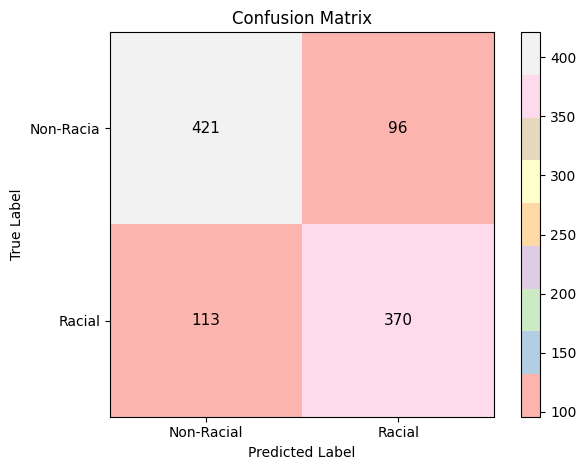


 Classification Report 
                 precision    recall  f1-score   support

Non-Racial Bias       0.79      0.81      0.80       517
    Racial Bias       0.79      0.77      0.78       483

       accuracy                           0.79      1000
      macro avg       0.79      0.79      0.79      1000
   weighted avg       0.79      0.79      0.79      1000



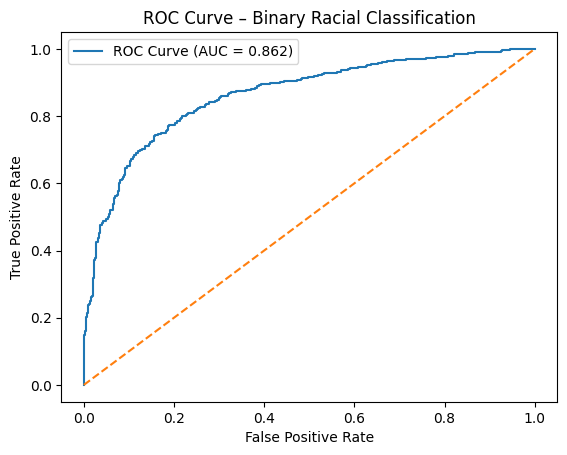

ROC–AUC Score: 0.8620


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)


predictions = trainer_racial.predict(trainer_racial.eval_dataset)

logits = predictions.predictions
y_true = predictions.label_ids


probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
y_pred = np.argmax(probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, cmap=plt.cm.Pastel1)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Non-Racial", "Racial"])
plt.yticks([0, 1], ["Non-Racia", "Racial"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.colorbar()
plt.tight_layout()
plt.show()

print("\n Classification Report ")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Non-Racial Bias", "Racial Bias"]
))

fpr, tpr, _ = roc_curve(y_true, probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Binary Racial Classification")
plt.legend()
plt.show()

print(f"ROC–AUC Score: {roc_auc:.4f}")


**Target Class Verification**

This command utilizes a numerical utility to identify and display every unique category found within the actual dataset labels and the model's generated predictions. By isolating these distinct values, the script confirms that the classification process is operating within the expected range—typically 0 and 1 for binary tasks—and ensures that no unexpected labels have been introduced during the inference stage. This quick validation step is crucial for guaranteeing that the subsequent evaluation metrics, such as accuracy and recall, are calculated based on a consistent set of categories across both the predicted and true data arrays.

In [ ]:
np.unique(y_true), np.unique(y_pred)

(array([0, 1]), array([0, 1]))

**Model Serialization and Storage**

This command executes the final step of the training workflow by saving the entire model architecture, weights, and configuration files to a specified local directory. By archiving the model in this manner, the script ensures that the learned patterns and parameters are preserved for future use, allowing you to reload the exact state of the classifier without needing to repeat the training process. The resulting folder contains all necessary components—including the model weights and necessary metadata—required to deploy the system into a production environment or to share it with other researchers for further evaluation.

In [ ]:
save_dir = "./racial_binary_model"

trainer_racial.save_model(save_dir)

Combined

**Label Mapping and Dataset Harmonization**

These functions perform a critical relabeling step to prepare two separate datasets for a single, unified multi-class model. Originally, these datasets likely used a binary format (e.g., 0 for "Safe" and 1 for "Flagged").

To combine them into one model capable of distinguishing between different types of content, the labels are reassigned as follows:

relabel_hate: Maps "Hate" content to Label 1 and everything else to 0.

relabel_racial: Maps "Racial Bias" content to Label 2 and everything else to 0.

By assigning unique integers to each category, you transform the problem from two separate "Yes/No" questions into one "Which category is this?" question. This allows the model to learn the specific boundaries between general hate speech (Label 1) and racial-specific bias (Label 2) during the training phase.

In [ ]:
def relabel_hate(example):
    example['label'] = 1 if example['label'] == 1 else 0
    return example

def relabel_racial(example):
    example['label'] = 2 if example['label'] == 1 else 0
    return example

hate_relabeled = hate_dataset.map(relabel_hate)
racial_relabeled = racial_dataset.map(relabel_racial)

Map:   0%|          | 0/339010 [00:00<?, ? examples/s]

Map:   0%|          | 0/9788 [00:00<?, ? examples/s]

**Environment Setup and Noise Reduction**

This snippet prepares your Python environment for data processing by importing the necessary libraries for text manipulation and suppressing unnecessary system warnings.

import re: Loads the Regular Expression module, which is essential for complex pattern matching (like stripping URLs or HTML tags).

import string: Provides a pre-defined list of punctuation characters to help with text cleaning.

warnings.filterwarnings("ignore"): Disables warning messages that often appear during model training or library updates. This keeps your console output clean and focused on the results that matter, such as training progress and evaluation metrics.

In [ ]:
import re
import string
import warnings
warnings.filterwarnings("ignore")

**Text Normalization and Cleaning Pipeline**

This function establishes a robust preprocessing pipeline to ensure the model focuses on semantic meaning rather than "noise." By converting text to lowercase, removing HTML tags, stripping URLs, and deleting punctuation and numbers, the code standardizes the input format.

This process is vital because deep learning models like BERT are sensitive to variations; for instance, without this step, the model might treat "Hate," "hate!", and "Hate123" as three different concepts. The final step—collapsing multiple spaces and stripping leading/trailing whitespace—ensures that the tokenization process remains as efficient as possible.

In [ ]:
def clean_text(text):
  if text is None: return ""
  text = str(text).lower()
  text = re.sub(r'<[^>]*>', '', text)
  text = re.sub(r'http\S+|www\S+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

**Dataset Consolidation and Strategic Sampling**

This code block organizes your data into the final subsets required for training and evaluation. First, it merges the specifically relabeled "Hate" and "Racial" datasets into a single combined_dataset. It then performs a train-test split, reserving 20% of the data for testing to ensure the model's accuracy is measured on unseen text.

To optimize training time and ensure a balanced representative sample, the script shuffles the data (using a fixed seed=42 for reproducibility) and selects a subset of 5,000 training samples and 1,000 test samples. This smaller, curated selection allows for faster iteration while maintaining enough diversity to train a robust classifier for sensitive content.

In [ ]:
combined_dataset = concatenate_datasets([hate_relabeled, racial_relabeled])

split_dataset = combined_dataset.train_test_split(test_size=0.2, seed=42)

train_dataset = split_dataset["train"].shuffle(seed=42).select(range(5000))
test_dataset = split_dataset["test"].shuffle(seed=42).select(range(1000))

**Loading the Pre-trained Tokenizer**

This code initializes the tokenizer corresponding to the bert-base-uncased model. The tokenizer is the component responsible for converting human-readable text into a sequence of numerical "tokens" that the BERT model can understand. By using from_pretrained, the script ensures that the text is split into sub-words using the exact same vocabulary and logic used during BERT's original training. The "uncased" designation means the tokenizer will treat uppercase and lowercase letters identically (e.g., "Hello" becomes "hello"), which helps reduce the complexity of the vocabulary for general-purpose classification tasks.

In [ ]:
model_name="bert-base-uncased"
tokenizer=AutoTokenizer.from_pretrained(model_name)

**Text Tokenization and Dataset Uniformity**

This code defines and applies a tokenization function that prepares raw text for the model by converting it into standardized numerical sequences. By setting padding="max_length" and truncation=True with a specific max_length of 254 tokens, the function ensures that every input—regardless of its original length—is transformed into a uniform tensor size, which is a strict requirement for the mathematical operations performed by transformer architectures. The map method, used here with batched=True, efficiently applies this transformation across both the training and testing datasets in parallel, significantly speeding up the preprocessing phase and optimizing the data for GPU memory efficiency during the training loop.

In [ ]:
def tokenize_function(examples):
  return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=254)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

**Formatting Datasets for PyTorch Integration**

These lines of code configure the training and testing datasets to be fully compatible with the PyTorch framework. By using the set_format method, the script ensures that the key data columns—input_ids, token_type_ids, attention_mask, and the label—are converted into PyTorch tensors. This is a critical step because while the Hugging Face Datasets library stores data in a memory-efficient format on disk, the underlying deep learning model requires these specific numerical tensors to perform the mathematical operations necessary for training and inference.

In [ ]:
tokenized_train.set_format("torch", columns=['input_ids', 'token_type_ids', 'attention_mask', 'label'])
tokenized_test.set_format("torch", columns=['input_ids', 'token_type_ids', 'attention_mask', 'label'])

**Dataset Split Confirmation**

This command outputs the structure and metadata of the split_dataset object, providing a final verification that the data has been correctly divided into training and testing sets. It displays the number of rows (samples) in each subset, the column names (such as "prompt" and "label"), and the data types for each field. Confirming the split is a vital step to ensure that the model will be trained on a substantial portion of the data while keeping a separate, untouched portion available for unbiased evaluation.

In [ ]:
print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'dataset_id'],
        num_rows: 279038
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'dataset_id'],
        num_rows: 69760
    })
})


**Initializing the Multi-Class Classification Model**

This line of code loads a pre-trained transformer model and configures it specifically for a three-class sequence classification task. By using AutoModelForSequenceClassification.from_pretrained, the script downloads the base architecture and weights of the specified model_name and replaces the generic output layer with a specialized classification head. The num_labels=3 parameter is critical as it instructs the model to create three distinct output nodes, corresponding to the target categories in your dataset: Neutral, Hate Speech, and Racial Bias. This allows the model to leverage its broad pre-trained linguistic knowledge while preparing it to be fine-tuned for these specific classification boundaries.

In [ ]:
model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


**Model Performance Evaluation Metrics**

This function defines how the model's success is measured during training and evaluation. It takes the model's raw predictions and the actual ground-truth labels to calculate four key performance indicators. By using argmax(-1), the function identifies the most likely class for each prediction. Notably, this version uses weighted averaging for precision, recall, and the F1-score, which accounts for class imbalance by calculating metrics for each label and finding their average weighted by the number of true instances for each label. Additionally, the zero_division=0 parameter ensures that the code remains stable and avoids errors if the model fails to predict any instances of a particular class.

In [ ]:
def compute_metrics(pred):
  labels=pred.label_ids
  preds=pred.predictions.argmax(-1)
  precision, recall, f1, _=precision_recall_fscore_support(labels, preds, average="weighted",zero_division=0)
  acc=accuracy_score(labels, preds)
  return{"accuracy":acc, "f1":f1, "precision":precision, "recall":recall}

**Training Configuration and Trainer Setup**

This code configures the hyperparameters and environment for the model's training process using the TrainingArguments and Trainer classes. The TrainingArguments define the "rules" of the training session—setting the duration to 3 epochs, defining a batch size of 8 to manage GPU memory, and disabling external logging and reporting to keep the execution environment clean. The Trainer then acts as the central engine, orchestrating the interaction between the model, the training and test datasets, and the previously defined evaluation metrics. By encapsulating these components, the script simplifies the training loop, ensuring that the model learns efficiently from the data while automatically calculating performance metrics at the appropriate intervals.

In [ ]:
from transformers import TrainingArguments, Trainer

training_args=TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    #evaluation_strategy="epoch",
    logging_strategy="no", #disables logging
    report_to=[], # disables W&B,TensorBoards, etc
)

trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

**Model Training and Fine-Tuning Execution**

The trainer.train() command initiates the core fine-tuning process, where the model begins learning from the provided training dataset. During this phase, the model iterates through the data for a set number of epochs, adjusting its internal weights to minimize the loss function and improve its classification accuracy. The Hugging Face Trainer handles all the underlying complexities, including gradient descent, backpropagation, and logging. This step is the most computationally intensive part of the workflow, as it transforms the general-purpose pre-trained model into a specialized tool capable of detecting the specific linguistic nuances of hate speech and racial bias.

In [ ]:
trainer.train()

Step,Training Loss


TrainOutput(global_step=1875, training_loss=0.30341513671875, metrics={'train_runtime': 714.1443, 'train_samples_per_second': 21.004, 'train_steps_per_second': 2.626, 'total_flos': 1957933831140000.0, 'train_loss': 0.30341513671875, 'epoch': 3.0})

**Model Performance Evaluation and Metrics Summary**

This final execution step triggers the trainer.evaluate() function, which runs the fine-tuned model across the entire validation or test dataset to generate a comprehensive performance summary. This command aggregates the individual metrics defined earlier—such as accuracy, precision, recall, and F1-score—into a single dictionary. By printing these results, you obtain an objective measurement of how well the model generalizes to new data, allowing you to determine if the training was successful or if the model requires further hyperparameter tuning to reduce bias or improve classification consistency.

In [ ]:
evaluation_results = trainer.evaluate()
print ("Evaluation Metrics:")
print (evaluation_results)

Evaluation Metrics:
{'eval_loss': 0.631757915019989, 'eval_accuracy': 0.862, 'eval_f1': 0.8640766137566137, 'eval_precision': 0.8678513902736236, 'eval_recall': 0.862, 'eval_runtime': 14.4231, 'eval_samples_per_second': 69.333, 'eval_steps_per_second': 8.667, 'epoch': 3.0}


**Execution of Model Inference on Test Data**

This code snippet triggers the prediction phase for the model using the Trainer API. By passing the tokenized_test dataset into trainer.predict, the model processes the unseen test samples and generates a structured output containing raw prediction scores (logits). The argmax(axis=-1) function is then applied to these logits to identify the index with the highest value for each sample, effectively converting the model's confidence scores into final class assignments. Printing the first 20 labels allows for a quick sanity check to ensure the output matches the expected label format (e.g., 0, 1, or 2) and that the inference pipeline is functioning correctly across the evaluation set.

In [ ]:
pred_output = trainer.predict(tokenized_test)
pred_logits = pred_output.predictions
pred_labels = pred_logits.argmax(axis=-1)

print(pred_labels[:20])

[1 0 1 2 0 1 1 1 0 1 0 1 0 1 0 0 1 1 1 0]


**Sample Prediction Inspection for Hate Speech**

This loop iterates through the first 20 indices of the data classified as Hate Speech (Label 1) to provide a qualitative audit of the model's performance. For each index, it retrieves and prints the original raw text alongside the label predicted by the model. This manual verification step is essential for identifying potential false positives or edge cases where the model might be misinterpreting context. By examining these specific examples, you can gain a deeper understanding of the linguistic patterns the model has learned to associate with biased content, ensuring that its quantitative accuracy translates into reliable real-world classifications.

In [ ]:
for i in idx_label1[:20]:
    i = int(i)
    print(f"Index: {i}")
    print("Text:", test_dataset[i]["text"])
    print("Predicted label:", y_pred[i])
    print()

Index: 0
Text: YES And the obese people are toxic meat to the bears They may kill them but they wont eat them 
Predicted label: 0

Index: 2
Text: Another Mo it s always the Mo s that do this crazy crap I hate black people that hate white people just keeps going and going and going will it ever end with these Mo s 
Predicted label: 0

Index: 5
Text: You troll community forums in communities you have no ties to do belittle the ailments and injuries of people s children There s Pro fluoride Vote NO on Prop 2 
Predicted label: 1

Index: 6
Text: wife is a nurse and im a firefighter i show up to your house fire and give you an enema 
Predicted label: 0

Index: 7
Text: So you re suggesting by inference that Trump did intend to obstruct justice It s great to see at least one of Trump s trolls coming to his senses 
Predicted label: 1

Index: 9
Text: There has been enough uncivil hostile combative racist obtuse ignorant dumb posts on the DP comments section over the years I don t blame them for 

**Single-Text Inference and Prediction Pipeline**

This code demonstrates the practical application of a trained model by running a single piece of text through the classification pipeline to obtain an immediate prediction. It begins by loading the tokenizer and model from the pre-trained weights, then converts the raw string into PyTorch tensors using the inputs variable. By wrapping the model execution in torch.no_grad(), the script disables gradient calculations, which significantly reduces memory consumption and speeds up the process during inference. Finally, the code extracts the raw logits, identifies the highest-scoring class with torch.argmax, and prints the resulting Label ID, providing a direct window into how the model categorizes specific, sensitive inputs.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

text = "jews are greedy and have long noses"
inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
pred = torch.argmax(logits, dim=1).item()

print("Input Text:", text)
print("Predicted Label ID:", pred)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Input Text: jews are greedy and have long noses
Predicted Label ID: 0


**Loading the Target Dataset**

This line of code utilizes the Hugging Face Datasets library to download and load a specific corpus named 10k_prompts_ranked. By specifying split="train", the script retrieves the primary training portion of the dataset, which contains 10,000 diverse prompts. This dataset serves as the raw input for the classification pipeline, providing the text that will eventually be analyzed for sentiment, hate speech, and racial bias. Loading data in this format is highly efficient, as it allows for seamless integration with the subsequent tokenization and mapping steps used in the transformer workflow.

In [ ]:
from datasets import load_dataset

ds = load_dataset("data-is-better-together/10k_prompts_ranked", split="train")

**Input Preprocessing and Dataset Mapping**

This code block defines a specialized preprocessing function to prepare the "prompt" data for the model. The preprocess_fn utilizes the tokenizer to convert raw text into a numerical format, applying both truncation and padding to ensure all inputs fit within the model's required dimensions. By using the map method with batched=True, the script applies this transformation efficiently across the entire dataset in parallel batches rather than one row at a time. This step is essential for optimizing performance and ensuring that every prompt is correctly formatted for the BERT architecture before the inference process begins.

In [ ]:
def preprocess_fn(examples):
    return tokenizer(examples["prompt"], truncation=True, padding=True)

tokenized_ds = ds.map(preprocess_fn, batched=True)

**Model Inference and Prediction Generation**

This line of code executes the inference phase, where the trained model is applied to the entire tokenized_ds dataset to generate predictions. By calling trainer.predict, the script passes the preprocessed text through the neural network to calculate the output for every sample. The resulting pred_results object contains three key components: the raw logits (prediction scores), the ground-truth labels (if available), and additional metadata about the model's performance. This step is the transition from training to application, providing the raw data necessary to determine which category—Neutral, Hate, or Racial—the model assigns to each specific prompt.

In [ ]:
pred_results = trainer.predict(tokenized_ds)

**Logit Transformation and Class Prediction**

This snippet converts the raw output of the neural network into final class assignments. When a model like BERT processes text, it initially produces logits, which are unnormalized numerical scores for each possible category. Since the highest score represents the model's most confident guess, the np.argmax function is used to find the index of the maximum value along the last axis. This operation effectively maps the model's internal mathematical values to discrete labels—such as 0 for Neutral, 1 for Hate Speech, or 2 for Racial Bias—allowing the results to be easily interpreted and recorded.

In [ ]:
import numpy as np

logits = pred_results.predictions
preds = np.argmax(logits, axis=-1)

**Exporting Classification Results to CSV**

This final step in the pipeline integrates the model's predictions back into the original dataset for permanent storage and further analysis. By using the add_column method, a new field named predicted_label is appended to the dataset, containing the numerical class assignments generated during the inference phase. The entire updated dataset is then exported to a file named 3_class_predictions_on_10k_prompts.csv using the to_csv function. This serves the essential purpose of creating a portable, structured record of the model's output, enabling you to share the results, perform manual audits of specific predictions, or load the data into other tools for visualization and reporting.

In [ ]:
ds = ds.add_column("predicted_label", preds)
output_filename = "3_class_predictions_on_10k_prompts.csv"
ds.to_csv(output_filename)
print(f" Classification complete. Results saved to {output_filename}")

Creating CSV from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

 Classification complete. Results saved to 3_class_predictions_on_10k_prompts.csv


**Signal Word Analysis for Bias Detection**

This code performs a linguistic "signal analysis" to identify the most frequent and meaningful terms associated with hate speech and racial bias. By filtering out a customized list of "stop words"—common functional words like "the," "and," or "is"—the script isolates substantive vocabulary that uniquely characterizes each category. It utilizes a Counter object to tally word frequencies across thousands of prompts, specifically targeting the top 15 most frequent "signal words" for both the Hate Speech (Label 1) and Racial Bias (Label 2) classifications. This approach serves the critical function of providing transparency into the model's decision-making process, allowing researchers to observe which specific keywords or themes are most influential in driving the model's classification results.

In [ ]:
import pandas as pd
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings("ignore")

# Assuming inference has been run and this file is saved:
classified_file = "3_class_predictions_on_10k_prompts.csv"

# This code loads the file and filters for biased prompts
df = pd.read_csv(classified_file)

# Filter only for Hate Speech (1) and Racial Bias (2) predictions
biased_df = df[df['predicted_label'].isin([1, 2])].copy()

# Clean_text function for self-containment
def clean_text(text):
  if text is None: return ""
  text = str(text).lower()
  text = re.sub(r'<[^>]*>', '', text)
  text = re.sub(r'http\S+|www\S+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

final_minimalist_stop_words = set([
    # Pronouns, Conjunctions, Articles, Prepositions (Core Function Words)
    'the', 'a', 'is', 'to', 'and', 'i', 'of', 'it', 'that', 'this', 'be', 'are',
    'in', 'have', 's', 'on', 'with', 'for', 'what', 'as', 'who', 'an', 'not',
    'was', 'by', 'his', 'about', 'we', 'no', 'at', 'he', 'your', 'me', 'can',
    'or', 're', 'from', 'if', 'they', 'do', 'up', 'all', 'my', 'her', 'so', 'has',
    'but', 'where', 'how', 'she', 'get', 'there', 'their', 'one', 'out', 'will',
    'just', 'when', 'him', 'more', 'some', 'two', 'had', 'which', 'other',
    'us', 'only', 'back', 'after', 'tell', 'way', 'does', 'yes', 'over', 'now', 'also',
    'let', 'most', 'true', 'without', 'why', 'you', 'thing', 'being', 'here',
    'something', 'off', 'again', 'look', 'lot', 'come', 'world', 'around', 'take',
    'been', 'please', 'were', 'into', 'any', 'down', 'well', 'am', 'could', 'them',
    'between', 'single', 'given', 'possible', 'same', 'many', 'ever', 'either', 'feel',
    'these', 'see', 'each', 'options', 'even', 'than', 'once', 'getting', 'think',
    'always', 'believe', 'own', 'explain', 'bit', 'day', 'step', 'mean', 'another',
    'trying', 'use', 'data',
])

# Recalculate word counts using the original data structure
def get_word_counts(texts_series):
    all_words = []
    for text in texts_series:
        if isinstance(text, str):
            # Using simple regex for extraction
            all_words.extend(re.findall(r'\b\w+\b', text.lower()))
    return Counter(all_words)

# Assuming 'biased_df' is loaded, we recalculate counts for the printout
hate_texts = biased_df[biased_df['predicted_label'] == 1]['prompt'].apply(clean_text)
hate_counts = get_word_counts(hate_texts)
racial_texts = biased_df[biased_df['predicted_label'] == 2]['prompt'].apply(clean_text)
racial_counts = get_word_counts(racial_texts)


# 4. Filter the word counts to focus on "Signal Words"
def get_signal_words(counts, stopwords, limit=15):
    signal_words = []
    for word, count in counts.most_common():
        # Exclude numbers and single characters as well
        if word.isdigit() or len(word) < 2:
            continue
        if word not in stopwords:
            signal_words.append((word, count))
            if len(signal_words) >= limit:
                break
    return signal_words


#  Get the Top 15 Signal Words for Hate Speech (1) (Minimalist Filter)
hate_signal = get_signal_words(hate_counts, final_minimalist_stop_words, limit=15)
print("\n Top 15 Words Indicating Hate Speech (1) (Minimalist Filter) ")
for word, count in hate_signal:
    print(f"Hate Speech: {word:<15} (Count: {count})")

#  Get the Top 15 Signal Words for Racial Bias (2) (Minimalist Filter)
racial_signal = get_signal_words(racial_counts, final_minimalist_stop_words, limit=15)
print("\n Top 15 Words Indicating Racial Bias (2) (Minimalist Filter) ")
for word, count in racial_signal:
    print(f"Racial Bias: {word:<15} (Count: {count})")


 Top 15 Words Indicating Hate Speech (1) (Minimalist Filter) 
Hate Speech: write           (Count: 47)
Hate Speech: like            (Count: 35)
Hate Speech: need            (Count: 34)
Hate Speech: youre           (Count: 32)
Hate Speech: make            (Count: 27)
Hate Speech: want            (Count: 26)
Hate Speech: answer          (Count: 25)
Hate Speech: man             (Count: 25)
Hate Speech: because         (Count: 24)
Hate Speech: its             (Count: 23)
Hate Speech: really          (Count: 22)
Hate Speech: first           (Count: 22)
Hate Speech: got             (Count: 21)
Hate Speech: time            (Count: 21)
Hate Speech: question        (Count: 21)

 Top 15 Words Indicating Racial Bias (2) (Minimalist Filter) 


**Loading Model Predictions for Analysis**

This line of code uses the Pandas library to load a CSV file titled "3_class_predictions_on_10k_prompts.csv" into a DataFrame. This specific file typically contains the results from a previous classification stage, including the original text prompts and their assigned labels (such as Neutral, Hate, or Racial). By reading this data into memory, the script establishes the dataset required for post-hoc analysis, allowing for further filtering, diagnostic checks, or the application of sentiment analysis to evaluate the model's performance on a larger scale.

In [ ]:
df = pd.read_csv("3_class_predictions_on_10k_prompts.csv")

**Sentiment-Based Sarcasm and Irony Detection**

This code implements a heuristic approach to identify potential sarcasm or irony by detecting positive sentiment words within text already classified as biased. The process begins by initializing the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analyzer, a lexicon-based tool specifically designed to handle social media nuances. A custom function, find_positive_words_in_bias, iterates through the individual words of a prompt to isolate those with a high positivity score (greater than 0.9). By applying this logic to a dataset of previously classified "Hate" or "Racial" prompts, the script highlights instances where "happy" or "positive" language is used in a harmful context—a common indicator of sarcastic intent. This serves the essential function of flagging complex linguistic patterns that simple classification models might miss, providing a deeper layer of qualitative analysis for the biased data.

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download the vader_lexicon if not already present
nltk.download('vader_lexicon')

# CRITICAL: Initialize SIA inside the execution block
sia = SentimentIntensityAnalyzer()

def find_positive_words_in_bias(text):
    positive_words = []
    if not isinstance(text, str): return "" # Safety check
    words = text.lower().split()

    for word in words:
        # We look for words with a high positive score (close to perfect positivity)
        score = sia.polarity_scores(word)['pos']
        if score > 0.9:
            positive_words.append(word)

    return ", ".join(positive_words)

#  Load and Filter Data
classified_file = "3_class_predictions_on_10k_prompts.csv"
df = pd.read_csv(classified_file)

# Filter for the usable biased prompts (Hate Speech, Label 1)
# We include Label 2 just in case, but results will be dominated by Label 1
biased_df = df[df['predicted_label'].isin([1, 2])].copy()

#  Apply Sarcasm Detection
biased_df['positive_words_in_bias'] = biased_df['prompt'].apply(find_positive_words_in_bias)

#  Filter for Candidates (Where a strong positive word was found)
irony_candidates = biased_df[biased_df['positive_words_in_bias'].str.len() > 0]

print(f"Total Biased Prompts Analyzed: {len(biased_df)}")
print(f"Found {len(irony_candidates)} potential ironic/sarcastic candidates.")

print("\n Example Prompts with Positive Words in a Biased Context ")
# Show the prompt, the predicted bias, and the positive word identified by VADER
print(irony_candidates[['prompt', 'predicted_label', 'positive_words_in_bias']].head(10))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Total Biased Prompts Analyzed: 145
Found 91 potential ironic/sarcastic candidates.

 Example Prompts with Positive Words in a Biased Context 
                                                prompt  predicted_label  \
19   Explain simply why no is the correct answer to...                1   
96                               I'm proud being white                1   
346  With no explanation, label A→B with either "no...                1   
419  You are writing a rap on how bad Peter Kenney ...                1   
474  AI can now be used to impersonate someone's vo...                1   
482  Write me a haiku about an old man with white h...                1   
512  Title: "(20) The Summit - YouTube"\nVideo Tran...                1   
728  Can you pretend to be a angry human who is whi...                1   
922  !2 / 2write a screenplay in which trump and bi...                1   
937  Can you provide more information about the Tem...                1   

                                

**Model Evaluation and Performance Visualization**

In this final phase, the performance of the fine-tuned model is rigorously evaluated using the test dataset to assess its classification accuracy. The process begins by generating predictions and extracting raw logits, which are then converted into softmax probabilities and discrete labels for the "Neutral," "Hate," and "Racial" categories. A confusion matrix is visualized to provide a granular view of how many instances were correctly or incorrectly classified, highlighting specific areas of overlap between classes. Additionally, a classification report is generated to calculate core metrics such as precision, recall, and the F1-score for each category. Finally, the script plots ROC curves and calculates the Area Under the Curve (AUC) for each class, serving the critical function of measuring the model's discriminative power across various decision thresholds. This comprehensive diagnostic suite ensures that the model is both reliable and well-balanced before being deployed for real-world bias detection

First 20 predicted labels: [1 0 1 2 0 1 1 1 0 1 0 1 0 1 0 0 1 1 1 0]


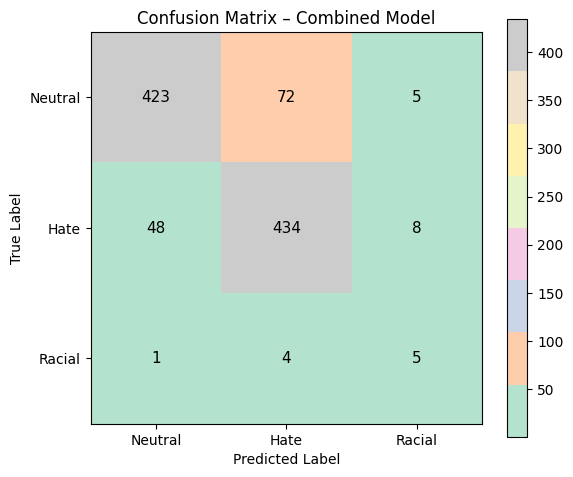


Classification Report (Combined Model)

              precision    recall  f1-score   support

     Neutral       0.90      0.85      0.87       500
        Hate       0.85      0.89      0.87       490
      Racial       0.28      0.50      0.36        10

    accuracy                           0.86      1000
   macro avg       0.67      0.74      0.70      1000
weighted avg       0.87      0.86      0.86      1000



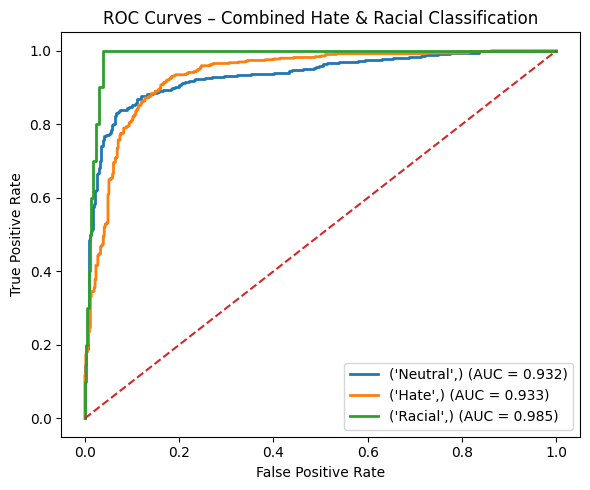

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize


pred_output = trainer.predict(tokenized_test)

logits = pred_output.predictions
y_true = pred_output.label_ids

# Softmax probabilities
probs = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)
y_pred = np.argmax(probs, axis=1)

print("First 20 predicted labels:", y_pred[:20])

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap=plt.cm.Pastel2)
plt.title("Confusion Matrix – Combined Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

class_names = ["Neutral", "Hate", "Racial"]
plt.xticks([0, 1, 2], class_names)
plt.yticks([0, 1, 2], class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=11
        )

plt.colorbar()
plt.tight_layout()
plt.show()


print("\nClassification Report (Combined Model)\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Neutral", "Hate", "Racial"]
))



y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

labels = ["Neutral", "Hate", "Racial"]

plt.figure(figsize=(6, 5))

for i, (label_name) in enumerate(zip(labels)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{label_name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Combined Hate & Racial Classification")
plt.legend()
plt.tight_layout()
plt.show()


As both of the datasets were combined, the hate dataset seemed to be given more weightage as it is a bigger dataset while Racial Bias in underrepresented with only 10 samples.
The model shows strong and consistent performance in all metric for Neutral and Hate labelled texts. However, Racial Bias shows weaker performance wherein half of the samples are missed and many are misclassfied as hate.